# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # define the encoder, latent parameter heads, and decoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        h1 = F.relu(self.fc1(x))
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# instantiate the model and move to device
model = VAE().to(device)
print("VAE model instantiated and moved to device")


VAE model instantiated and moved to device


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

In [3]:
def vae_loss(recon_x, x, mu, logvar):
    x_flat = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy(recon_x, x_flat, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [ ]:
# Hyperparameters
# TODO: choose appropriate batch size, number of epochs, and learning rate
batch_size = 128
epochs = 15
learning_rate = 0.001

# Data transformation and loading
# TODO: add any preprocessing needed for MNIST
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# create the optimizer after the model has been defined
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()
for epoch in range(1, epochs + 1):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch: {epoch} Average loss: {avg_loss:.4f}')


Epoch: 1 Average loss: 163.8401
Epoch: 2 Average loss: 120.9502
Epoch: 3 Average loss: 114.5942
Epoch: 4 Average loss: 111.6910
Epoch: 5 Average loss: 109.9370
Epoch: 6 Average loss: 108.7132
Epoch: 7 Average loss: 107.8361
Epoch: 8 Average loss: 107.1883
Epoch: 9 Average loss: 106.6447
Epoch: 10 Average loss: 106.2645
Epoch: 11 Average loss: 105.8689
Epoch: 12 Average loss: 105.5554
Epoch: 13 Average loss: 105.2557
Epoch: 14 Average loss: 105.0121
Epoch: 15 Average loss: 104.8066


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

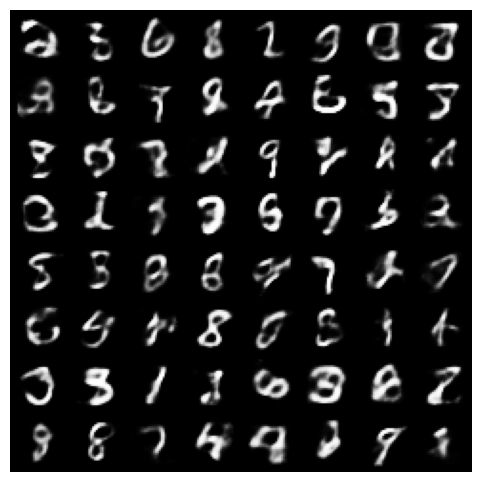

In [5]:
model.eval()
with torch.no_grad():
    latent_dim = model.fc_mu.out_features
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z)
    samples = samples.view(-1, 1, 28, 28).cpu()
    import torchvision.utils as vutils
    grid = vutils.make_grid(samples, nrow=8, padding=2, normalize=True)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0), cmap='gray')
    plt.axis('off')
    plt.show()
